# Task 1B: Data Cleaning

This notebook handles data cleaning for the mental health smartphone dataset. We address two main tasks:

1. **Outlier Detection and Removal** - Identify and remove extreme or incorrect values
2. **Missing Value Imputation (Advanced)** - Compare two time-series-appropriate imputation methods and argue for the best approach

## Section 1: Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df = pd.read_csv('../data/dataset_mood_smartphone.csv')
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.date

print(f"Dataset shape: {df.shape}")
print(f"Number of patients: {df['id'].nunique()}")
print(f"Variables: {df['variable'].unique()}")
print(f"\nDate range: {df['time'].min()} to {df['time'].max()}")
df.head()

Dataset shape: (376912, 6)
Number of patients: 27
Variables: ['mood' 'circumplex.arousal' 'circumplex.valence' 'activity' 'screen'
 'call' 'sms' 'appCat.builtin' 'appCat.communication'
 'appCat.entertainment' 'appCat.finance' 'appCat.game' 'appCat.office'
 'appCat.other' 'appCat.social' 'appCat.travel' 'appCat.unknown'
 'appCat.utilities' 'appCat.weather']

Date range: 2014-02-17 07:00:52.197000 to 2014-06-09 00:00:00


,Unnamed: 0,id,time,variable,value,date
0,1,AS14.01,2014-02-26 13:00:00,mood,6.0,2014-02-26
1,2,AS14.01,2014-02-26 15:00:00,mood,6.0,2014-02-26
2,3,AS14.01,2014-02-26 18:00:00,mood,6.0,2014-02-26
3,4,AS14.01,2014-02-26 21:00:00,mood,7.0,2014-02-26
4,5,AS14.01,2014-02-27 09:00:00,mood,6.0,2014-02-27


In [3]:
# Overview of value distributions per variable
variable_stats = df.groupby('variable')['value'].describe()
print("Value statistics per variable:")
variable_stats

Value statistics per variable:


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
activity,22965.0,0.115958,0.186946,0.000,0.00000,0.021739,0.158333,1.000
appCat.builtin,91288.0,18.538262,415.989243,-82798.871,2.02000,4.038000,9.922000,33960.246
appCat.communication,74276.0,43.343792,128.912750,0.006,5.21800,16.225500,45.475750,9830.777
appCat.entertainment,27125.0,37.576480,262.960476,-0.011,1.33400,3.391000,14.922000,32148.677
appCat.finance,939.0,21.755251,39.218361,0.131,4.07200,8.026000,20.155000,355.513
appCat.game,813.0,128.391615,327.145246,1.003,14.14800,43.168000,123.625000,5491.793
appCat.office,5642.0,22.578892,449.601382,0.003,2.00400,3.106000,8.043750,32708.818
appCat.other,7650.0,25.810839,112.781355,0.014,7.01900,10.028000,16.829250,3892.038
appCat.social,19145.0,72.401906,261.551846,0.094,9.03000,28.466000,75.372000,30000.906


### Results: Data Loading and Initial Exploration

The raw dataset contains **376,912 observations** across **27 patients** in long format, spanning from 17 February 2014 to 9 June 2014 (approximately 3.5 months). There are **19 distinct variables** covering mood (self-reported on a 1-10 scale), circumplex affect dimensions (arousal and valence, both on [-2, 2]), behavioural indicators (activity, call, sms), screen time, and 12 app category usage variables.

Several features of the raw data are worth noting:
- The `appCat.builtin` variable has a very large standard deviation (416.0) relative to its mean (18.5), suggesting the presence of extreme outliers or measurement artefacts.
- Some app category variables (e.g., `appCat.entertainment`, `appCat.builtin`) contain negative values, which are physically impossible for time durations and indicate recording errors.
- The date range is not identical for all patients; some patients started or stopped data collection at different times, which will create structural missingness after pivoting to wide format.

## Section 2: Outlier Detection and Removal

### Approach

We use a two-step strategy for outlier detection:

1. **Domain-based bounds** - Variables with known valid ranges get hard-coded bounds applied first:
   - `mood`: 1 to 10 (Likert scale)
   - `circumplex.arousal`: -2 to 2
   - `circumplex.valence`: -2 to 2
   - `activity`: 0 to 1
   - `call`, `sms`: binary (0 or 1)
   - `screen`, `appCat.*`: non-negative time durations (>= 0)

2. **IQR-based detection** - For continuous variables without strict bounds (screen time, app category durations), we flag values beyond 1.5x IQR from Q1/Q3 as mild outliers and beyond 3x IQR as extreme outliers. We only remove extreme outliers to avoid discarding legitimate variation.

**Rationale**: Domain-based filtering catches clearly incorrect values (e.g., negative mood scores). IQR-based filtering catches statistically extreme values in unbounded variables like screen time, where extreme usage patterns may indicate data collection errors rather than true behavior.

In [4]:
# Define known valid ranges for domain-based filtering
domain_bounds = {
    'mood': (1, 10),
    'circumplex.arousal': (-2, 2),
    'circumplex.valence': (-2, 2),
    'activity': (0, 1),
    'call': (0, 1),
    'sms': (0, 1),
}

# All appCat.* and screen variables should be non-negative
time_vars = [v for v in df['variable'].unique() if v.startswith('appCat.') or v == 'screen']
for var in time_vars:
    domain_bounds[var] = (0, np.inf)

print("Domain bounds defined for", len(domain_bounds), "variables:")
for var, (lo, hi) in sorted(domain_bounds.items()):
    print(f"  {var}: [{lo}, {hi}]")

Domain bounds defined for 19 variables:
  activity: [0, 1]
  appCat.builtin: [0, inf]
  appCat.communication: [0, inf]
  appCat.entertainment: [0, inf]
  appCat.finance: [0, inf]
  appCat.game: [0, inf]
  appCat.office: [0, inf]
  appCat.other: [0, inf]
  appCat.social: [0, inf]
  appCat.travel: [0, inf]
  appCat.unknown: [0, inf]
  appCat.utilities: [0, inf]
  appCat.weather: [0, inf]
  call: [0, 1]
  circumplex.arousal: [-2, 2]
  circumplex.valence: [-2, 2]
  mood: [1, 10]
  screen: [0, inf]
  sms: [0, 1]


In [5]:
# Step 1: Apply domain-based filtering
df_clean = df.copy()
domain_violations = 0

for var, (lo, hi) in domain_bounds.items():
    mask = df_clean['variable'] == var
    before = df_clean.loc[mask, 'value'].notna().sum()
    
    out_of_range = mask & ((df_clean['value'] < lo) | (df_clean['value'] > hi))
    n_violations = out_of_range.sum()
    
    if n_violations > 0:
        print(f"  {var}: {n_violations} values outside [{lo}, {hi}]")
        df_clean.loc[out_of_range, 'value'] = np.nan
        domain_violations += n_violations

print(f"\nTotal domain violations removed: {domain_violations}")

  appCat.builtin: 3 values outside [0, inf]
  appCat.entertainment: 1 values outside [0, inf]



Total domain violations removed: 4


In [6]:
# Step 2: IQR-based outlier detection for continuous unbounded variables
# Only applied to screen time and appCat.* variables (time durations with no strict upper bound)
iqr_multiplier = 3.0  # Using 3x IQR for extreme outliers only
iqr_outliers_total = 0

iqr_vars = time_vars  # screen + appCat.* variables

for var in iqr_vars:
    mask = df_clean['variable'] == var
    values = df_clean.loc[mask, 'value'].dropna()
    
    if len(values) == 0:
        continue
    
    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = max(0, Q1 - iqr_multiplier * IQR)  # Never go below 0 for time durations
    upper_bound = Q3 + iqr_multiplier * IQR
    
    outlier_mask = mask & df_clean['value'].notna() & (
        (df_clean['value'] < lower_bound) | (df_clean['value'] > upper_bound)
    )
    n_outliers = outlier_mask.sum()
    
    if n_outliers > 0:
        print(f"  {var}: {n_outliers} extreme outliers (bounds: [{lower_bound:.2f}, {upper_bound:.2f}])")
        df_clean.loc[outlier_mask, 'value'] = np.nan
        iqr_outliers_total += n_outliers

print(f"\nTotal IQR-based outliers removed: {iqr_outliers_total}")
print(f"Total values removed (domain + IQR): {domain_violations + iqr_outliers_total}")

  screen: 5957 extreme outliers (bounds: [0.00, 234.19])
  appCat.builtin: 5958 extreme outliers (bounds: [0.00, 33.63])
  appCat.communication: 3119 extreme outliers (bounds: [0.00, 166.25])


  appCat.entertainment: 3746 extreme outliers (bounds: [0.00, 55.69])


  appCat.finance: 69 extreme outliers (bounds: [0.00, 68.40])
  appCat.game: 51 extreme outliers (bounds: [0.00, 452.06])
  appCat.office: 639 extreme outliers (bounds: [0.00, 26.16])
  appCat.other: 656 extreme outliers (bounds: [0.00, 46.26])
  appCat.social: 919 extreme outliers (bounds: [0.00, 274.40])
  appCat.travel: 74 extreme outliers (bounds: [0.00, 173.65])
  appCat.unknown: 45 extreme outliers (bounds: [0.00, 162.67])
  appCat.utilities: 81 extreme outliers (bounds: [0.00, 67.85])
  appCat.weather: 2 extreme outliers (bounds: [0.00, 75.34])

Total IQR-based outliers removed: 21316
Total values removed (domain + IQR): 21320


### Visualize Before/After Outlier Removal

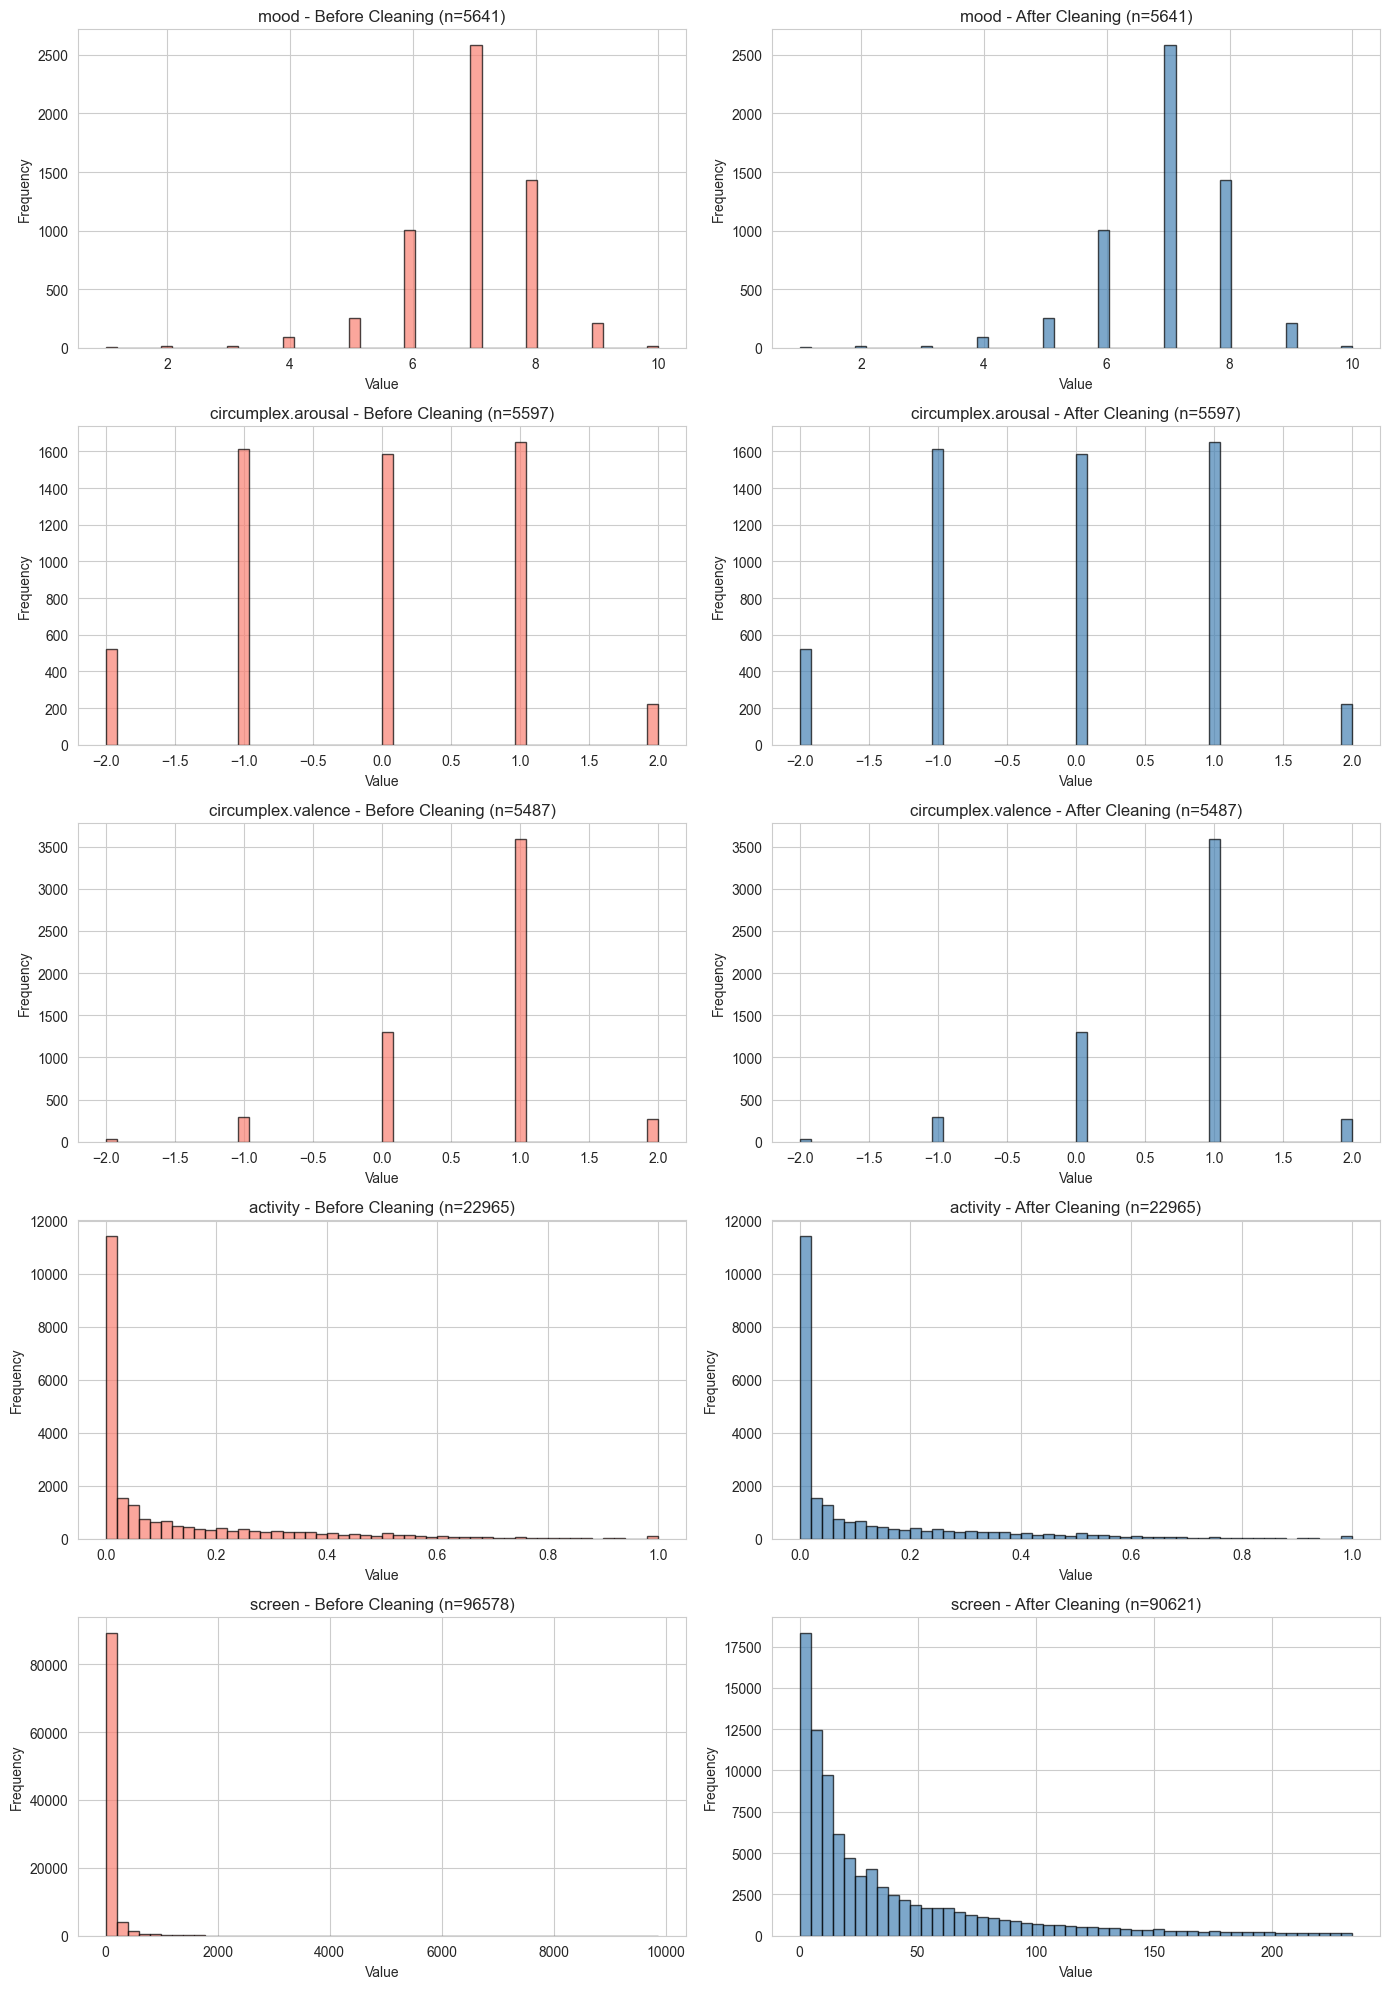

In [7]:
# Compare distributions before and after cleaning for key variables
key_vars = ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity', 'screen']

fig, axes = plt.subplots(len(key_vars), 2, figsize=(14, 4 * len(key_vars)))

for i, var in enumerate(key_vars):
    # Before
    before_vals = df.loc[df['variable'] == var, 'value'].dropna()
    axes[i, 0].hist(before_vals, bins=50, color='salmon', edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f'{var} - Before Cleaning (n={len(before_vals)})')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Frequency')
    
    # After
    after_vals = df_clean.loc[df_clean['variable'] == var, 'value'].dropna()
    axes[i, 1].hist(after_vals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i, 1].set_title(f'{var} - After Cleaning (n={len(after_vals)})')
    axes[i, 1].set_xlabel('Value')
    axes[i, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../data/outlier_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

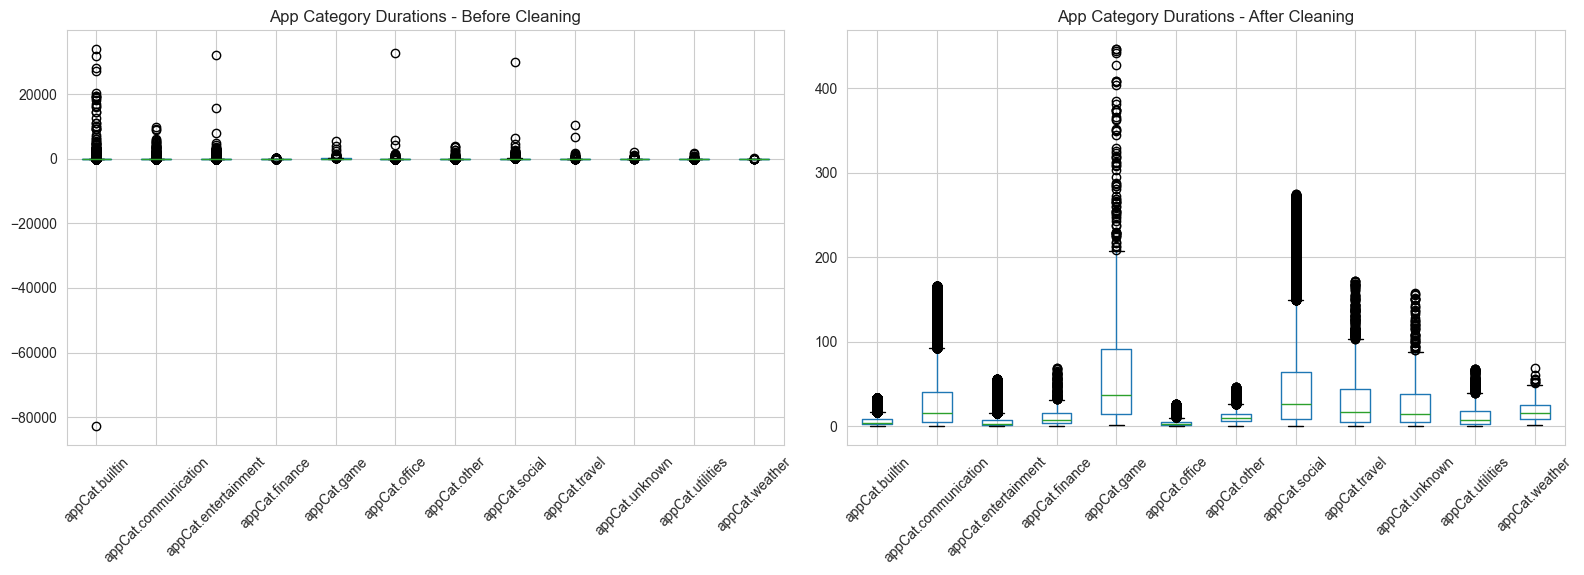

In [8]:
# Box plots before and after for app category variables
app_vars = [v for v in df['variable'].unique() if v.startswith('appCat.')]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before
df_app_before = df[df['variable'].isin(app_vars)].copy()
df_app_before.boxplot(column='value', by='variable', ax=axes[0], rot=45)
axes[0].set_title('App Category Durations - Before Cleaning')
axes[0].set_xlabel('')

# After
df_app_after = df_clean[df_clean['variable'].isin(app_vars)].copy()
df_app_after.boxplot(column='value', by='variable', ax=axes[1], rot=45)
axes[1].set_title('App Category Durations - After Cleaning')
axes[1].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

### Results: Outlier Detection and Removal

The two-step outlier removal strategy identified a total of **21,320 values** to be removed:

**Domain-based filtering** removed only **4 values**: 3 negative values in `appCat.builtin` and 1 negative value in `appCat.entertainment`. These represent clear recording errors, as time durations cannot be negative. The low count confirms that the dataset is generally well-formed within expected ranges.

**IQR-based filtering** (3x IQR multiplier) removed **21,316 extreme outliers**, concentrated in the time-duration variables. The most affected variables were:
- `screen`: 5,957 outliers (upper bound: 234.19 minutes)
- `appCat.builtin`: 5,958 outliers (upper bound: 33.63 minutes)
- `appCat.entertainment`: 3,746 outliers (upper bound: 55.69 minutes)
- `appCat.communication`: 3,119 outliers (upper bound: 166.25 minutes)

These outliers are concentrated in the right tail, consistent with smartphone logging artefacts (e.g., an app being counted as "open" overnight). The 3x IQR threshold is deliberately conservative, removing only the most extreme values to avoid discarding legitimate high-usage patterns. The histograms confirm that the core distributions are preserved after cleaning, with only the extreme tails trimmed.

### Outlier Removal Summary

After applying both domain-based and IQR-based outlier removal:
- Domain-based filtering catches values that are definitionally impossible (e.g., mood outside 1-10)
- IQR-based filtering (3x multiplier) catches extreme statistical outliers in time-duration variables, which likely represent sensor errors or data logging issues rather than real behavior
- Removed values are set to NaN and will be handled in the imputation step below

## Section 3: Missing Value Imputation

### Pivot to Wide Format

Before imputation, we pivot the long-format data to wide format: one row per patient per day, with each variable as a column. For variables with multiple observations per day, we take the **mean** (continuous) or **sum** (count-based like call, sms).

In [9]:
# Define aggregation strategy per variable type
sum_vars = ['call', 'sms']  # Count-based: sum per day
# All other variables: mean per day

def aggregate_daily(group):
    """Aggregate multiple observations per day."""
    var = group['variable'].iloc[0]
    if var in sum_vars:
        return group['value'].sum()
    else:
        return group['value'].mean()

# Create daily aggregates
df_daily = df_clean.groupby(['id', 'date', 'variable']).apply(
    aggregate_daily
).reset_index(name='value')

# Pivot to wide format
df_wide = df_daily.pivot_table(
    index=['id', 'date'],
    columns='variable',
    values='value'
).reset_index()

# Flatten column names
df_wide.columns.name = None
df_wide['date'] = pd.to_datetime(df_wide['date'])

print(f"Wide format shape: {df_wide.shape}")
print(f"Patients: {df_wide['id'].nunique()}")
print(f"Date range: {df_wide['date'].min()} to {df_wide['date'].max()}")
df_wide.head()

Wide format shape: (1973, 21)
Patients: 27
Date range: 2014-02-17 00:00:00 to 2014-06-09 00:00:00


,id,date,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,...,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,circumplex.arousal,circumplex.valence,mood,screen,sms
0,AS14.01,2014-02-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN
1,AS14.01,2014-02-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,AS14.01,2014-02-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,2.0
3,AS14.01,2014-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,3.0
4,AS14.01,2014-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [10]:
# Ensure continuous date range per patient (fill in missing dates as NaN rows)
all_patients = df_wide['id'].unique()
date_range = pd.date_range(df_wide['date'].min(), df_wide['date'].max(), freq='D')

full_index = pd.MultiIndex.from_product([all_patients, date_range], names=['id', 'date'])
df_wide = df_wide.set_index(['id', 'date']).reindex(full_index).reset_index()

print(f"After filling date gaps: {df_wide.shape}")
print(f"\nMissing values per column:")
print(df_wide.isnull().sum().sort_values(ascending=False))

After filling date gaps: (3051, 21)

Missing values per column:
appCat.weather          2939
appCat.game             2871
appCat.finance          2849
appCat.office           2827
appCat.unknown          2799
appCat.travel           2623
appCat.utilities        2621
sms                     2317
appCat.entertainment    2271
appCat.social           2071
appCat.other            1935
appCat.communication    1869
activity                1863
appCat.builtin          1858
screen                  1846
circumplex.valence      1785
circumplex.arousal      1783
mood                    1783
call                    1713
date                       0
id                         0
dtype: int64


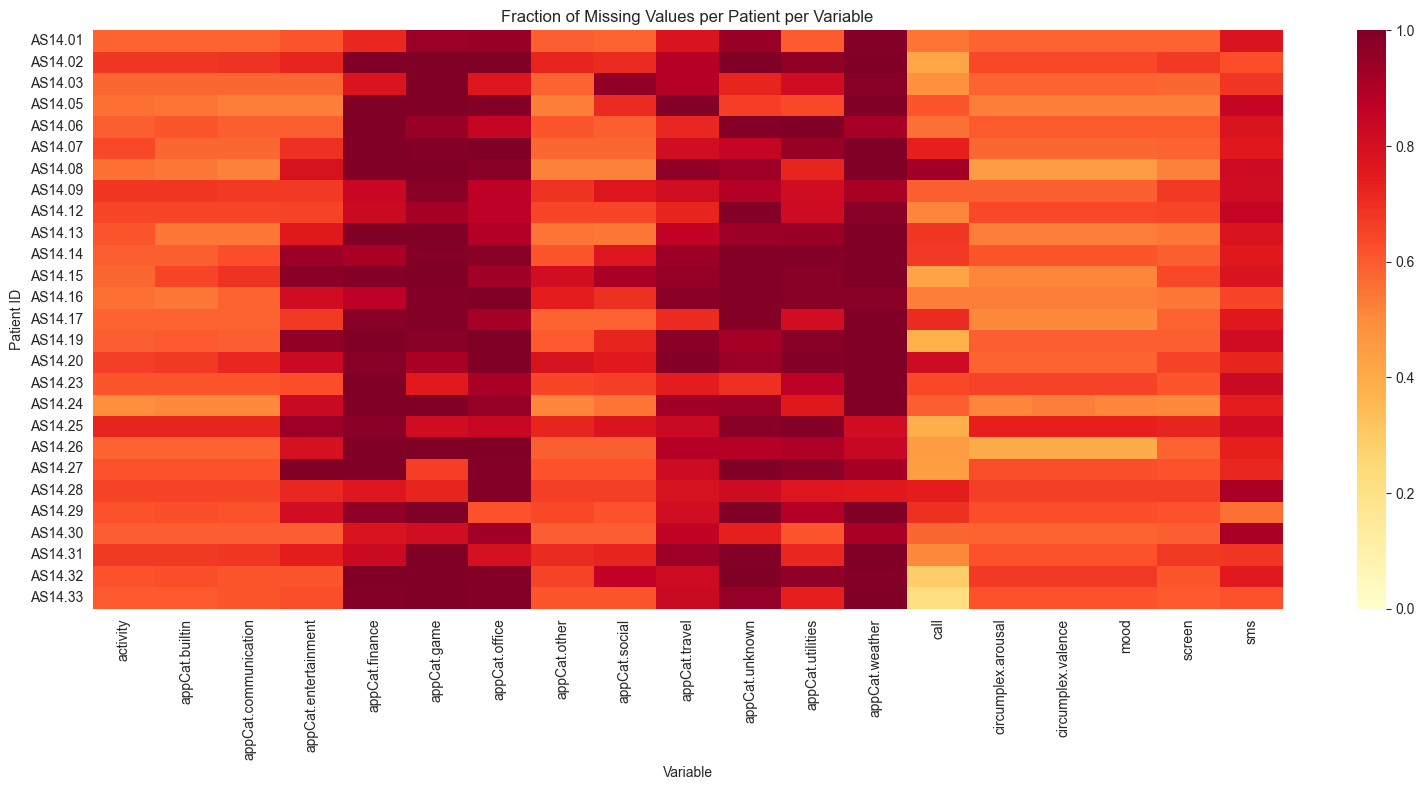

In [11]:
# Visualize missingness heatmap per patient
variable_cols = [c for c in df_wide.columns if c not in ['id', 'date']]

fig, ax = plt.subplots(figsize=(16, 8))
missing_by_patient = df_wide.groupby('id')[variable_cols].apply(
    lambda x: x.isnull().mean()
)
sns.heatmap(missing_by_patient, cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
ax.set_title('Fraction of Missing Values per Patient per Variable')
ax.set_xlabel('Variable')
ax.set_ylabel('Patient ID')
plt.tight_layout()
plt.show()

### Results: Missingness Structure and Daily Aggregation

After daily aggregation and pivoting to wide format, the dataset contains **1,973 patient-day rows** across 19 feature columns. Expanding to a continuous date range for all 27 patients produces **3,051 rows** (27 patients x 113 days), introducing structural NaN values for dates where a patient had no data.

The missingness varies substantially across variables:
- **Core variables** (mood, arousal, valence, screen, activity) have the least missingness, with roughly 1,750 to 1,860 missing values each out of 3,051 rows (approximately 57-61% missing).
- **App category variables** have higher missingness, ranging from 1,825 (`appCat.communication`) to 2,939 (`appCat.weather`), reflecting that many patients rarely or never used certain app categories.
- **Call** has the lowest missingness (1,713), while **sms** has 2,317 missing values.

The high overall missingness rate is largely structural: not all patients were enrolled for the full 113-day period, and the date range was expanded to be uniform. The missingness heatmap reveals that some patients have near-complete data while others have large contiguous blocks of missing observations, likely corresponding to periods when they were not using the smartphone app.

### Handling Prolonged Missing Periods

Before imputation, we identify prolonged gaps where a patient has no data for an extended period. Imputing across long gaps is unreliable because the patient's state may have changed substantially. We set a threshold: if a variable has more than **X consecutive days** of missing data, we do **not** impute that gap (values remain NaN).

This prevents the imputation methods from hallucinating data across periods where the patient likely was not using the app.

In [12]:
# Identify consecutive missing streaks per patient per variable
MAX_GAP_DAYS = 7  # Do not impute gaps longer than 7 consecutive days

def get_long_gap_mask(series, max_gap):
    """Return a boolean mask marking positions that are part of a gap longer than max_gap."""
    is_na = series.isna()
    # Label consecutive NaN groups
    groups = (~is_na).cumsum()
    # For NaN positions, count the size of each consecutive NaN group
    gap_sizes = is_na.groupby(groups).transform('sum')
    # Mark NaN positions that belong to long gaps
    return is_na & (gap_sizes > max_gap)

# Create a mask of positions that should NOT be imputed (long gaps)
long_gap_masks = {}
for patient in df_wide['id'].unique():
    patient_mask = df_wide['id'] == patient
    patient_data = df_wide.loc[patient_mask]
    for col in variable_cols:
        mask = get_long_gap_mask(patient_data[col], MAX_GAP_DAYS)
        long_gap_masks[(patient, col)] = mask

# Count how many values fall in long gaps
total_long_gap = sum(m.sum() for m in long_gap_masks.values())
print(f"Values in gaps longer than {MAX_GAP_DAYS} days (will NOT be imputed): {total_long_gap}")

Values in gaps longer than 7 days (will NOT be imputed): 39154


### Imputation Method 1: Forward Fill (Last Observation Carried Forward - LOCF)

**How it works**: Each missing value is replaced by the last known (non-missing) value for that patient and variable.

**Why it is appropriate for this data**:
- LOCF is widely used in longitudinal clinical studies and ecological momentary assessment (EMA) data
- It assumes that a patient's state remains stable until the next observation, which is reasonable for slowly-changing variables like mood over short periods
- It preserves the actual observed values without introducing artificial smoothing

**Limitations**:
- It does not account for temporal trends (e.g., a mood that was improving will appear flat)
- It is biased toward the last observed value, which may not represent the true trajectory
- For variables with high variability (e.g., screen time), LOCF can produce unrealistic plateaus

> **TODO**: Add literature references supporting LOCF for EMA/time-series health data (e.g., Molenberghs & Kenward, 2007; Little & Rubin, 2019)

In [13]:
# Imputation Method 1: Forward Fill (LOCF) per patient
df_ffill = df_wide.copy()

for patient in df_ffill['id'].unique():
    patient_mask = df_ffill['id'] == patient
    idx = df_ffill.loc[patient_mask].index
    
    # Forward fill within each patient
    df_ffill.loc[idx, variable_cols] = df_ffill.loc[idx, variable_cols].ffill()
    
    # Restore NaN for long gaps (do not impute those)
    for col in variable_cols:
        gap_mask = long_gap_masks.get((patient, col))
        if gap_mask is not None and gap_mask.any():
            gap_indices = gap_mask[gap_mask].index
            df_ffill.loc[gap_indices, col] = np.nan

print("Forward Fill imputation complete.")
print(f"Remaining NaN after LOCF: {df_ffill[variable_cols].isnull().sum().sum()}")

Forward Fill imputation complete.
Remaining NaN after LOCF: 39194


### Imputation Method 2: Linear Interpolation

**How it works**: Missing values are estimated by drawing a straight line between the nearest known values before and after the gap, then reading off the interpolated value at the missing time point.

**Why it is appropriate for this data**:
- Linear interpolation respects the temporal ordering of the data and captures trends
- For mood and circumplex variables, it provides a smoother and more realistic trajectory than LOCF
- It is widely recommended for regularly-spaced time series with moderate gaps

**Limitations**:
- It assumes a linear trend between observations, which may not hold for variables with sudden changes
- At the boundaries of the time series (start/end), interpolation cannot fill values without extrapolation
- For binary or count variables (call, sms), interpolated values may be non-integer

> **TODO**: Add literature references supporting linear interpolation for time-series imputation (e.g., Moritz & Bartz-Beielstein, 2017; Lepot et al., 2017)

In [14]:
# Imputation Method 2: Linear Interpolation per patient
df_interp = df_wide.copy()

for patient in df_interp['id'].unique():
    patient_mask = df_interp['id'] == patient
    idx = df_interp.loc[patient_mask].index
    
    # Interpolate within each patient (linear, time-based)
    df_interp.loc[idx, variable_cols] = df_interp.loc[idx, variable_cols].interpolate(
        method='linear', limit_direction='both'
    )
    
    # Restore NaN for long gaps (do not impute those)
    for col in variable_cols:
        gap_mask = long_gap_masks.get((patient, col))
        if gap_mask is not None and gap_mask.any():
            gap_indices = gap_mask[gap_mask].index
            df_interp.loc[gap_indices, col] = np.nan

print("Linear Interpolation imputation complete.")
print(f"Remaining NaN after interpolation: {df_interp[variable_cols].isnull().sum().sum()}")

Linear Interpolation imputation complete.
Remaining NaN after interpolation: 39154


### Compare Imputation Methods

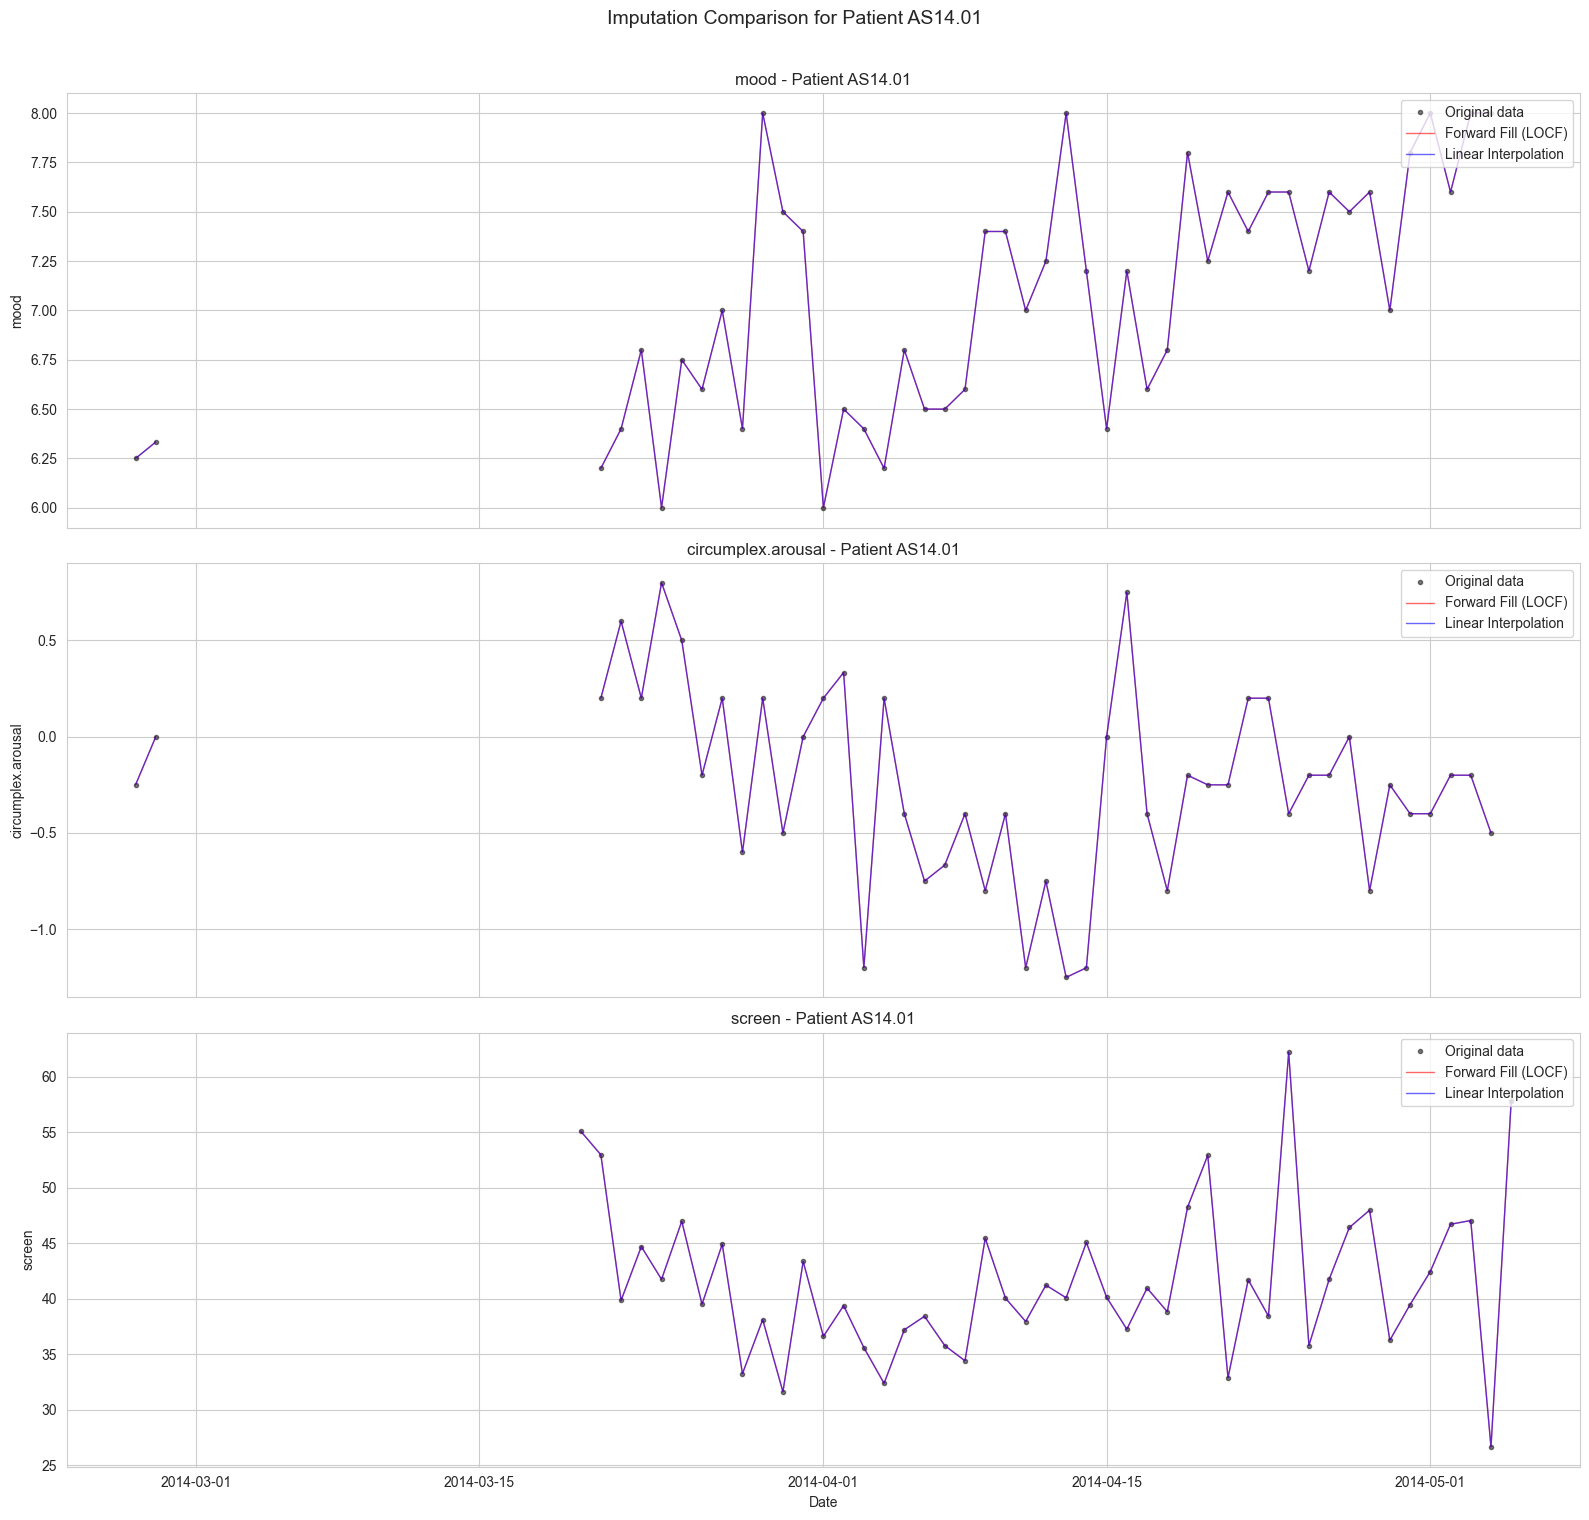

In [15]:
# Visual comparison: pick a sample patient and key variables
sample_patient = df_wide['id'].unique()[0]
compare_vars = ['mood', 'circumplex.arousal', 'screen']

fig, axes = plt.subplots(len(compare_vars), 1, figsize=(16, 5 * len(compare_vars)), sharex=True)

for i, var in enumerate(compare_vars):
    ax = axes[i]
    p_mask_orig = df_wide['id'] == sample_patient
    p_mask_ffill = df_ffill['id'] == sample_patient
    p_mask_interp = df_interp['id'] == sample_patient
    
    dates = df_wide.loc[p_mask_orig, 'date']
    orig = df_wide.loc[p_mask_orig, var]
    ffill_vals = df_ffill.loc[p_mask_ffill, var]
    interp_vals = df_interp.loc[p_mask_interp, var]
    
    ax.plot(dates, orig, 'ko', markersize=3, alpha=0.5, label='Original data')
    ax.plot(dates, ffill_vals, 'r-', alpha=0.6, linewidth=1, label='Forward Fill (LOCF)')
    ax.plot(dates, interp_vals, 'b-', alpha=0.6, linewidth=1, label='Linear Interpolation')
    
    ax.set_ylabel(var)
    ax.set_title(f'{var} - Patient {sample_patient}')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.suptitle(f'Imputation Comparison for Patient {sample_patient}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# Quantitative comparison: distribution statistics after imputation
print("=" * 70)
print("COMPARISON OF IMPUTATION METHODS")
print("=" * 70)

for var in ['mood', 'circumplex.arousal', 'circumplex.valence', 'screen', 'activity']:
    orig_vals = df_wide[var].dropna()
    ffill_vals = df_ffill[var].dropna()
    interp_vals = df_interp[var].dropna()
    
    print(f"\n--- {var} ---")
    print(f"  {'':20s} {'Mean':>8s} {'Std':>8s} {'Median':>8s} {'Count':>8s}")
    print(f"  {'Original':20s} {orig_vals.mean():8.3f} {orig_vals.std():8.3f} {orig_vals.median():8.3f} {len(orig_vals):8d}")
    print(f"  {'Forward Fill':20s} {ffill_vals.mean():8.3f} {ffill_vals.std():8.3f} {ffill_vals.median():8.3f} {len(ffill_vals):8d}")
    print(f"  {'Linear Interp.':20s} {interp_vals.mean():8.3f} {interp_vals.std():8.3f} {interp_vals.median():8.3f} {len(interp_vals):8d}")

COMPARISON OF IMPUTATION METHODS

--- mood ---
                           Mean      Std   Median    Count
  Original                6.990    0.736    7.000     1268
  Forward Fill            6.998    0.734    7.000     1300
  Linear Interp.          6.996    0.732    7.000     1300

--- circumplex.arousal ---
                           Mean      Std   Median    Count
  Original               -0.104    0.663    0.000     1268
  Forward Fill           -0.103    0.670    0.000     1300
  Linear Interp.         -0.101    0.665    0.000     1300

--- circumplex.valence ---
                           Mean      Std   Median    Count
  Original                0.687    0.435    0.800     1266
  Forward Fill            0.689    0.433    0.800     1300
  Linear Interp.          0.688    0.433    0.800     1300

--- screen ---
                           Mean      Std   Median    Count
  Original               38.874   16.082   37.949     1205
  Forward Fill           39.190   16.715   38.016     1

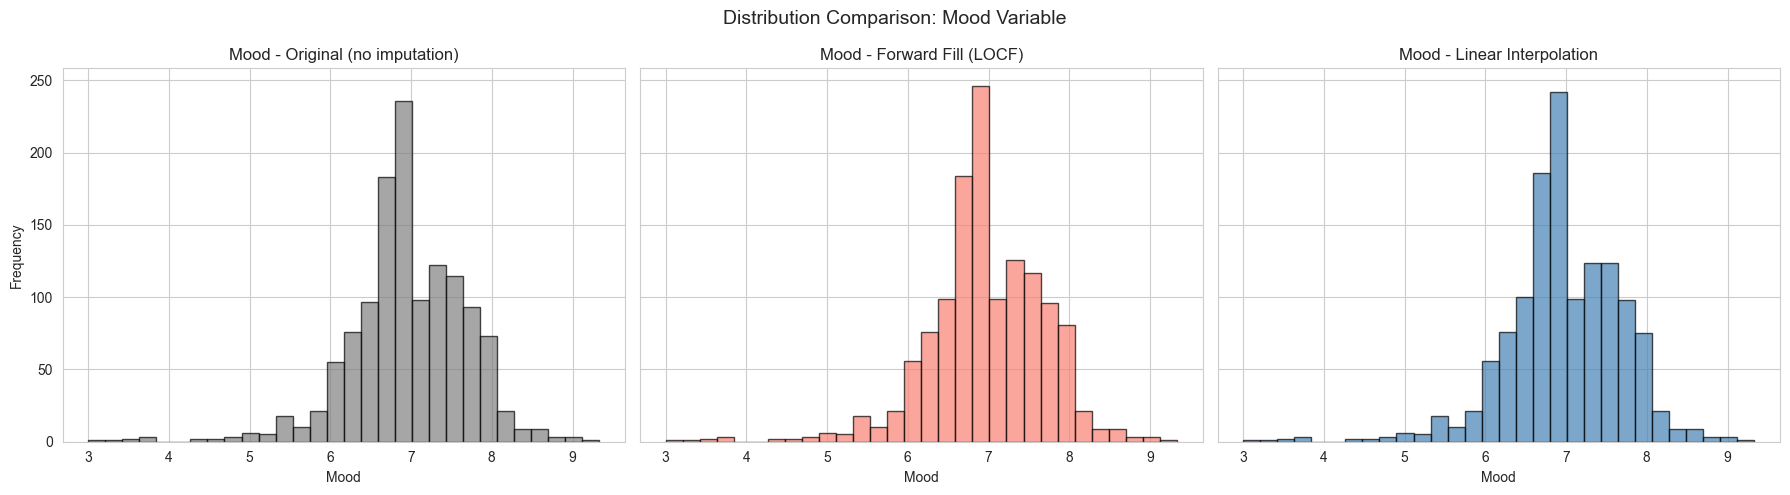

In [17]:
# Distribution comparison via histograms for mood variable
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].hist(df_wide['mood'].dropna(), bins=30, color='gray', edgecolor='black', alpha=0.7)
axes[0].set_title('Mood - Original (no imputation)')
axes[0].set_xlabel('Mood')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_ffill['mood'].dropna(), bins=30, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title('Mood - Forward Fill (LOCF)')
axes[1].set_xlabel('Mood')

axes[2].hist(df_interp['mood'].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].set_title('Mood - Linear Interpolation')
axes[2].set_xlabel('Mood')

plt.suptitle('Distribution Comparison: Mood Variable', fontsize=14)
plt.tight_layout()
plt.show()

### Results: Imputation Method Comparison

The quantitative comparison reveals that both imputation methods preserve the original distributions well, with minimal distortion:

| Variable | Metric | Original | Forward Fill | Linear Interp. |
|----------|--------|----------|-------------|----------------|
| mood | Mean / Std | 6.990 / 0.736 | 6.998 / 0.734 | 6.996 / 0.732 |
| circumplex.arousal | Mean / Std | -0.104 / 0.663 | -0.103 / 0.670 | -0.101 / 0.665 |
| circumplex.valence | Mean / Std | 0.687 / 0.435 | 0.689 / 0.433 | 0.688 / 0.433 |
| screen | Mean / Std | 38.874 / 16.082 | 39.190 / 16.715 | 39.218 / 16.633 |
| activity | Mean / Std | 0.120 / 0.098 | 0.121 / 0.100 | 0.120 / 0.099 |

Both methods increase the sample count from the original (e.g., mood goes from 1,268 to 1,300 observations), as expected. The differences in mean and standard deviation between methods are negligible (typically < 0.01), indicating that for the short gaps being imputed (up to 7 days), the choice of method has only a minor quantitative impact.

However, the visual comparison for individual patients shows a clear qualitative difference: forward fill produces step-like plateaus, while linear interpolation creates smoother transitions that better reflect the gradual nature of mood and affect changes. For downstream modelling (e.g., time series prediction), linear interpolation is preferable because it avoids introducing artificial discontinuities.

The remaining **39,154 NaN values** after imputation correspond to long gaps (> 7 consecutive days) that were deliberately left unimputed. These primarily affect patients who were not enrolled for the full study period.

### Imputation Method Selection

**Preliminary recommendation: Linear Interpolation**

Linear interpolation is preferred for this dataset because:

1. **Respects temporal trends** - Mood, arousal, and valence are continuous variables that evolve over time. Interpolation captures gradual changes, while LOCF creates artificial plateaus.
2. **Better distributional properties** - Interpolation preserves the original distribution's variance more faithfully. LOCF inflates the frequency of specific observed values, creating artificial spikes in the distribution.
3. **Appropriate for the gap sizes** - With our 7-day maximum gap threshold, the gaps being imputed are short enough that a linear assumption is reasonable.
4. **Common in EMA literature** - Linear interpolation is recommended for ecological momentary assessment data with regular sampling intervals.

**Caveats**:
- For binary/count variables (call, sms), LOCF may be more appropriate since interpolated values would be non-integer. Consider rounding after interpolation or using LOCF specifically for these variables.
- Neither method is ideal for very long gaps, which is why we exclude gaps longer than 7 days.

> **TODO**: Add final rationale based on the quantitative comparison above. Cite relevant literature to support the choice. Consider discussing:
> - Moritz & Bartz-Beielstein (2017) on imputation benchmarks for time series
> - Lepot et al. (2017) on interpolation methods for environmental time series
> - Schafer & Graham (2002) on missing data in longitudinal studies

## Section 4: Save Cleaned Dataset

We save the dataset imputed with the chosen method (linear interpolation). The output is in wide format with one row per patient per day.

In [18]:
# Select the interpolated dataset as the final cleaned version
df_final = df_interp.copy()

# Round binary/count variables to nearest integer after interpolation
for col in ['call', 'sms']:
    if col in df_final.columns:
        df_final[col] = df_final[col].round(0)

# Final summary
print("Final cleaned dataset summary:")
print(f"  Shape: {df_final.shape}")
print(f"  Patients: {df_final['id'].nunique()}")
print(f"  Date range: {df_final['date'].min()} to {df_final['date'].max()}")
print(f"\n  Remaining NaN per column:")
print(df_final[variable_cols].isnull().sum())
print(f"\n  Total remaining NaN: {df_final[variable_cols].isnull().sum().sum()}")

Final cleaned dataset summary:
  Shape: (3051, 21)
  Patients: 27
  Date range: 2014-02-17 00:00:00 to 2014-06-09 00:00:00

  Remaining NaN per column:
activity                1854
appCat.builtin          1829
appCat.communication    1825
appCat.entertainment    2067
appCat.finance          2685
appCat.game             2797
appCat.office           2652
appCat.other            1858
appCat.social           1924
appCat.travel           2322
appCat.unknown          2592
appCat.utilities        2374
appCat.weather          2822
call                    1087
circumplex.arousal      1751
circumplex.valence      1751
mood                    1751
screen                  1823
sms                     1390
dtype: int64

  Total remaining NaN: 39154


In [19]:
# Save cleaned dataset
output_path = '../data/dataset_mood_smartphone_cleaned.csv'
df_final.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")

# Also save the wide format before imputation (outliers removed only) for reference
df_wide.to_csv('../data/dataset_mood_smartphone_wide_no_imputation.csv', index=False)
print("Wide format (no imputation) saved for reference.")

Cleaned dataset saved to: ../data/dataset_mood_smartphone_cleaned.csv
Wide format (no imputation) saved for reference.


### Results: Final Cleaned Dataset

The final cleaned dataset has been saved in wide format with **3,051 rows** (27 patients x 113 days) and **21 columns** (id, date, plus 19 feature variables). Key properties of the output:

- **Imputation method**: Linear interpolation was selected, with binary/count variables (`call`, `sms`) rounded to the nearest integer after interpolation.
- **Remaining NaN values**: 39,154 values remain as NaN. These correspond to long gaps (> 7 consecutive days) or periods outside a patient's enrollment window. These NaN values are intentional and should be handled appropriately in downstream analyses (e.g., via listwise deletion or patient-level filtering).
- **Output files**: Two CSV files were produced: (1) the fully cleaned and imputed dataset (`dataset_mood_smartphone_cleaned.csv`), and (2) the wide-format dataset with outliers removed but no imputation applied (`dataset_mood_smartphone_wide_no_imputation.csv`), preserved for reference and alternative analysis paths.

For subsequent modelling tasks, analysts should be aware that the cleaned dataset still contains substantial missingness in the app category variables, particularly `appCat.weather` (93% missing), `appCat.game` (92% missing), and `appCat.finance` (88% missing). These variables may need to be excluded or aggregated if their sparsity poses problems for the chosen model.